# Assignment 4: Deep Neural Network

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=6, suppress=True)

## Part A — Perceptron From Scratch

### A1. Implement the Step Function

In [2]:
def unit_step(x):
    # Return 1 when x >= 0, otherwise return 0
    return 1 if x >= 0 else 0


# Test with positive, negative, and zero inputs
print("unit_step(5):", unit_step(5))
print("unit_step(-5):", unit_step(-5))
print("unit_step(0):", unit_step(0))

unit_step(5): 1
unit_step(-5): 0
unit_step(0): 1


### A2. Implement a Perceptron Class

In [3]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.mistakes_per_epoch = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.weights = np.zeros(X.shape[1])
        self.bias = 0.0
        self.mistakes_per_epoch = []

        for _ in range(self.epochs):
            mistakes = 0

            for xi, target in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                prediction = unit_step(z)

                error = target - prediction

                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    mistakes += 1

            self.mistakes_per_epoch.append(mistakes)

        return self

    def predict(self, X):
        X = np.asarray(X)
        scores = X @ self.weights + self.bias
        return np.array([unit_step(score) for score in scores])

### A3. Train on AND

In [4]:
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([0, 0, 0, 1])

and_model = Perceptron(learning_rate=0.1, epochs=20)
and_model.fit(X_and, y_and)

and_predictions = and_model.predict(X_and)
and_accuracy = np.mean(and_predictions == y_and)

print("Final weights:", and_model.weights)
print("Final bias:", and_model.bias)
print("Predictions:", and_predictions)
print("Accuracy:", and_accuracy)
print("Mistakes per epoch:", and_model.mistakes_per_epoch)

Final weights: [0.2 0.1]
Final bias: -0.20000000000000004
Predictions: [0 0 0 1]
Accuracy: 1.0
Mistakes per epoch: [2, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### A4. AND Decision Boundary

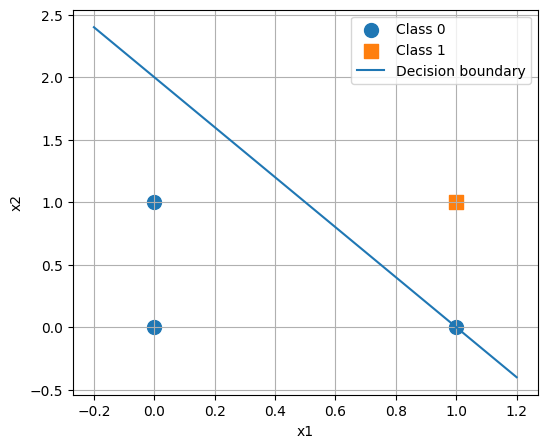

In [7]:
plt.figure(figsize=(6, 5))

for label, marker in [(0, "o"), (1, "s")]:
    mask = y_and == label
    plt.scatter(
        X_and[mask, 0],
        X_and[mask, 1],
        marker=marker,
        s=100,
        label=f"Class {label}"
    )

x1 = np.linspace(-0.2, 1.2, 50)

if abs(and_model.weights[1]) > 1e-12:
    x2 = -(and_model.weights[0] * x1 + and_model.bias) / and_model.weights[1]
    plt.plot(x1, x2, label="Decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

## Part B — Linear Separability and XOR

### B1/B2. XOR Dataset, Analyse Perceptron Failure

Final weights: [-0.1  0. ]
Final bias: 0.0
Predictions: [1 1 0 0]
Accuracy: 0.5
Number of mistakes per epoch: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


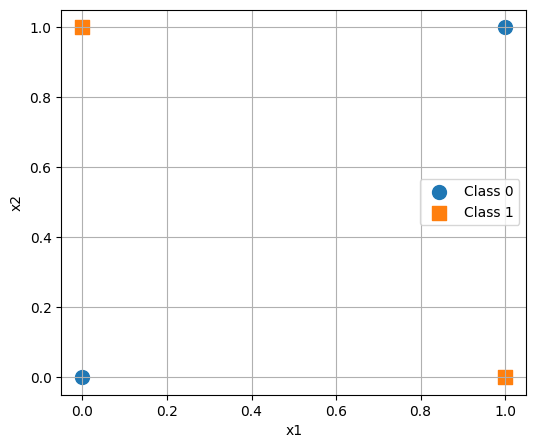

In [10]:
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])

xor_model = Perceptron(learning_rate=0.1, epochs=20)
xor_model.fit(X_xor, y_xor)

xor_predictions = xor_model.predict(X_xor)
xor_accuracy = np.mean(xor_predictions == y_xor)

print("Final weights:", xor_model.weights)
print("Final bias:", xor_model.bias)
print("Predictions:", xor_predictions)
print("Accuracy:", xor_accuracy)
print("Number of mistakes per epoch:", xor_model.mistakes_per_epoch)

plt.figure(figsize=(6, 5))

for label, marker in [(0, "o"), (1, "s")]:
    mask = y_xor == label
    plt.scatter(
        X_xor[mask, 0],
        X_xor[mask, 1],
        marker=marker,
        s=100,
        label=f"Class {label}"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

## Part C — Breast Cancer Wisconsin Dataset

### C1. Dataset Exploration

In [11]:
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", data.target_names)
print("Features:")
for i, feature in enumerate(data.feature_names, start=1):
    print(f"{i:2d}. {feature}")

print("\nClass counts:")
for class_value, class_name in enumerate(data.target_names):
    print(f"{class_value} ({class_name}):", np.sum(y == class_value))

print("\nMissing values:", np.isnan(X).sum())
print("\nFeature means:")
print(np.mean(X, axis=0))
print("\nFeature standard deviations:")
print(np.std(X, axis=0))

X shape: (569, 30)
y shape: (569,)
Classes: ['malignant' 'benign']
Features:
 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension

Class counts:
0 (malignant): 212
1 (benign): 357

Missing values: 0

Feature means:
[ 14.127292  19.289649  91.969033 654.889104   0.09636    0.104341
   0.088799   0.048919   0.181162   0.062798   0.405172   1.216853
   2.866059  40.337079   0.007041   0.025478   0.031894   0.011796
   0.020542   0.003795  16.26919

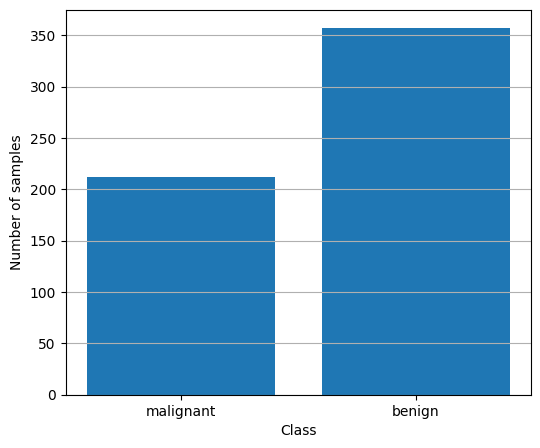

In [12]:
class_counts = np.bincount(y)

plt.figure(figsize=(6, 5))
plt.bar(data.target_names, class_counts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.grid(axis="y")
plt.show()

### C2. Train/Test Split and Standardization

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (455, 30)
Testing shape: (114, 30)


## Activation Functions and Their Derivatives

In [26]:
LEAKY_ALPHA = 0.01
PRELU_ALPHA = 0.01
ELU_ALPHA = 1.0
SELU_LAMBDA = 1.0507009873554805
SELU_ALPHA = 1.6732632423543772

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    t = np.tanh(x)
    return 1.0 - t**2

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def leaky_relu(x):
    return np.where(x > 0, x, LEAKY_ALPHA * x)

def leaky_relu_derivative(x):
    return np.where(x > 0, 1.0, LEAKY_ALPHA)

def prelu(x):
    return np.where(x > 0, x, PRELU_ALPHA * x)

def prelu_derivative(x):
    return np.where(x > 0, 1.0, PRELU_ALPHA)

def elu(x):
    return np.where(x > 0, x, ELU_ALPHA * (np.exp(x) - 1.0))

def elu_derivative(x):
    return np.where(x > 0, 1.0, ELU_ALPHA * np.exp(x))

def selu(x):
    return SELU_LAMBDA * np.where(
        x > 0,
        x,
        SELU_ALPHA * (np.exp(x) - 1.0)
    )

def selu_derivative(x):
    return SELU_LAMBDA * np.where(
        x > 0,
        1.0,
        SELU_ALPHA * np.exp(x)
    )

def softplus(x):
    return np.logaddexp(0, x)

def softplus_derivative(x):
    return sigmoid(x)

def gelu(x):
    erf_values = np.array([special.erf(v / np.sqrt(2)) for v in np.ravel(x)])
    erf_values = erf_values.reshape(np.shape(x))
    return 0.5 * x * (1.0 + erf_values)

def gelu_derivative(x):
    pdf = np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)
    cdf = 0.5 * (1.0 + np.array([special.erf(v / np.sqrt(2)) for v in np.ravel(x)]).reshape(np.shape(x)))
    return cdf + x * pdf

def silu(x):
    return x * sigmoid(x)

def silu_derivative(x):
    s = sigmoid(x)
    return s + x * s * (1.0 - s)

def mish(x):
    sp = softplus(x)
    return x * np.tanh(sp)

def mish_derivative(x):
    sp = softplus(x)
    t = np.tanh(sp)
    s = sigmoid(x)
    return t + x * s * (1.0 - t**2)


ACTIVATIONS = {
    "Sigmoid": (sigmoid, sigmoid_derivative),
    "Tanh": (tanh, tanh_derivative),
    "ReLU": (relu, relu_derivative),
    "Leaky ReLU": (leaky_relu, leaky_relu_derivative),
    "PReLU": (prelu, prelu_derivative),
    "ELU": (elu, elu_derivative),
    "SELU": (selu, selu_derivative),
    "Softplus": (softplus, softplus_derivative),
    "GELU": (gelu, gelu_derivative),
    "SiLU/Swish": (silu, silu_derivative),
    "Mish": (mish, mish_derivative),
}

## Part C/D — MLP Initialization, Forward Propagation, and Binary Cross-Entropy Loss

In [16]:
def initialize_parameters(seed=42):
    rng = np.random.default_rng(seed)

    parameters = {
        "W1": rng.standard_normal((30, 16)) * 0.01,
        "b1": np.zeros((1, 16)),
        "W2": rng.standard_normal((16, 8)) * 0.01,
        "b2": np.zeros((1, 8)),
        "W3": rng.standard_normal((8, 1)) * 0.01,
        "b3": np.zeros((1, 1)),
    }

    return parameters


def forward(X, parameters, activation=relu):
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]
    W3, b3 = parameters["W3"], parameters["b3"]

    Z1 = X @ W1 + b1
    A1 = activation(Z1)

    Z2 = A1 @ W2 + b2
    A2 = activation(Z2)

    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "A3": A3,
    }

    return A1, A2, A3, cache


def binary_cross_entropy(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)

    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )


parameters = initialize_parameters(seed=42)
_, _, initial_predictions, initial_cache = forward(
    X_train,
    parameters,
    activation=relu
)

print("Initial training loss:", binary_cross_entropy(y_train, initial_predictions))

Initial training loss: 0.6931496354946161


In [17]:
# Display one test sample through the complete forward pass

A1_sample, A2_sample, A3_sample, cache_sample = forward(
    X_test[:1],
    parameters,
    activation=relu
)

print("X:", X_test[:1])
print("Z1:", cache_sample["Z1"])
print("A1:", A1_sample)
print("Z2:", cache_sample["Z2"])
print("A2:", A2_sample)
print("Z3:", cache_sample["Z3"])
print("A3 (prediction probability):", A3_sample)

X: [[ 1.568513  2.164016  1.742866  1.620764 -0.265376  1.915932  1.092455
   1.698896  0.309589 -0.069884  1.658233 -0.034558  2.199279  1.609795
  -0.232337  1.198715  0.187957  0.559817 -0.162073  0.523832  1.86216
   1.708208  2.170622  1.913701 -0.18774   1.744275  0.68856   1.202144
  -0.140431  0.900362]]
Z1: [[-0.064913 -0.061304  0.137684  0.009902 -0.006549 -0.062563 -0.008969
   0.094471 -0.002967 -0.040911  0.068428  0.054787 -0.094751  0.025596
  -0.011098 -0.1069  ]]
A1: [[0.       0.       0.137684 0.009902 0.       0.       0.       0.094471
  0.       0.       0.068428 0.054787 0.       0.025596 0.       0.      ]]
Z2: [[-0.002889  0.001411 -0.005823 -0.003534  0.001049  0.000923 -0.001229
  -0.003448]]
A2: [[0.       0.001411 0.       0.       0.001049 0.000923 0.       0.      ]]
Z3: [[-0.000003]]
A3 (prediction probability): [[0.499999]]


## Part E — Backpropagation

### E1–E3. Chain Rule

In [18]:
def backward(X, y, cache, parameters, activation_derivative=relu_derivative):
    y = np.asarray(y).reshape(-1, 1)
    m = len(X)

    W2 = parameters["W2"]
    W3 = parameters["W3"]

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    Z2 = cache["Z2"]
    A2 = cache["A2"]
    A3 = cache["A3"]

    dZ3 = A3 - y
    dW3 = A2.T @ dZ3 / m
    db3 = np.mean(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * activation_derivative(Z2)
    dW2 = A1.T @ dZ2 / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * activation_derivative(Z1)
    dW1 = X.T @ dZ1 / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    gradients = {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
        "W3": dW3,
        "b3": db3,
    }

    return gradients

## Part F — Gradient Descent and Training

In [19]:
def update_parameters(parameters, gradients, learning_rate):
    for key in parameters:
        parameters[key] -= learning_rate * gradients[key]

    return parameters


def train(
    X,
    y,
    learning_rate=0.01,
    epochs=2000,
    activation=relu,
    activation_derivative=relu_derivative,
    seed=42
):
    parameters = initialize_parameters(seed=seed)
    loss_history = []

    for epoch in range(epochs):
        _, _, predictions, cache = forward(
            X,
            parameters,
            activation=activation
        )

        loss = binary_cross_entropy(y, predictions)
        loss_history.append(loss)

        gradients = backward(
            X,
            y,
            cache,
            parameters,
            activation_derivative=activation_derivative
        )

        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )

    return parameters, loss_history

In [20]:
def predict_proba(X, parameters, activation=relu):
    _, _, probabilities, _ = forward(
        X,
        parameters,
        activation=activation
    )
    return probabilities.ravel()


def predict(X, parameters, activation=relu, threshold=0.5):
    probabilities = predict_proba(X, parameters, activation)
    return (probabilities >= threshold).astype(int)


def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0.0
    )

    confusion_matrix = np.array([
        [tn, fp],
        [fn, tp]
    ])

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": confusion_matrix,
    }

===== MLP: BREAST CANCER WISCONSIN =====
Training samples: 455
Testing samples: 114
Number of features: 30

===== TRAINING =====
Final training loss: 0.6608144761806146
Epochs: 2000

===== TEST RESULTS =====
Test loss: 0.6581504958938486
Accuracy: 0.631578947368421
Precision: 0.631578947368421
Recall: 1.0
F1-score: 0.7741935483870968

Confusion Matrix:
[[ 0 42]
 [ 0 72]]


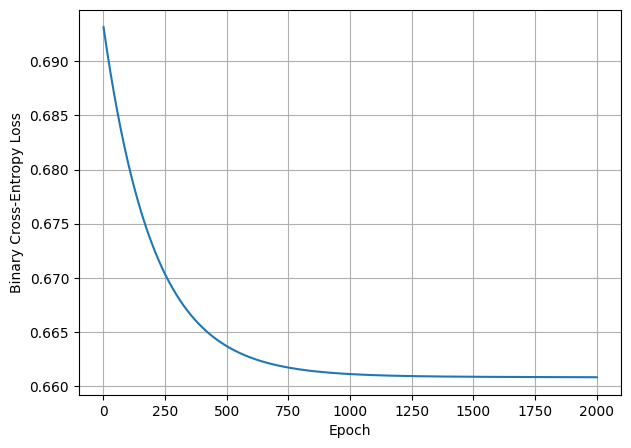

In [22]:
learning_rate = 0.01
epochs = 2000

parameters_relu, loss_history_relu = train(
    X_train,
    y_train,
    learning_rate=learning_rate,
    epochs=epochs,
    activation=relu,
    activation_derivative=relu_derivative,
    seed=42
)

train_prob = predict_proba(X_train, parameters_relu, relu)
test_prob = predict_proba(X_test, parameters_relu, relu)

train_pred = (train_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

train_metrics = classification_metrics(y_train, train_pred)
test_metrics = classification_metrics(y_test, test_pred)

train_loss = binary_cross_entropy(y_train, train_prob)
test_loss = binary_cross_entropy(y_test, test_prob)

print("===== MLP: BREAST CANCER WISCONSIN =====")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", X_train.shape[1])

print("\n===== TRAINING =====")
print("Final training loss:", train_loss)
print("Epochs:", epochs)

print("\n===== TEST RESULTS =====")
print("Test loss:", test_loss)
print("Accuracy:", test_metrics["accuracy"])
print("Precision:", test_metrics["precision"])
print("Recall:", test_metrics["recall"])
print("F1-score:", test_metrics["f1"])

print("\nConfusion Matrix:")
print(test_metrics["confusion_matrix"])

plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), loss_history_relu)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.show()

## Part G — Comprehensive Activation Function Analysis

### G1/G2. Implement and Verify Activations

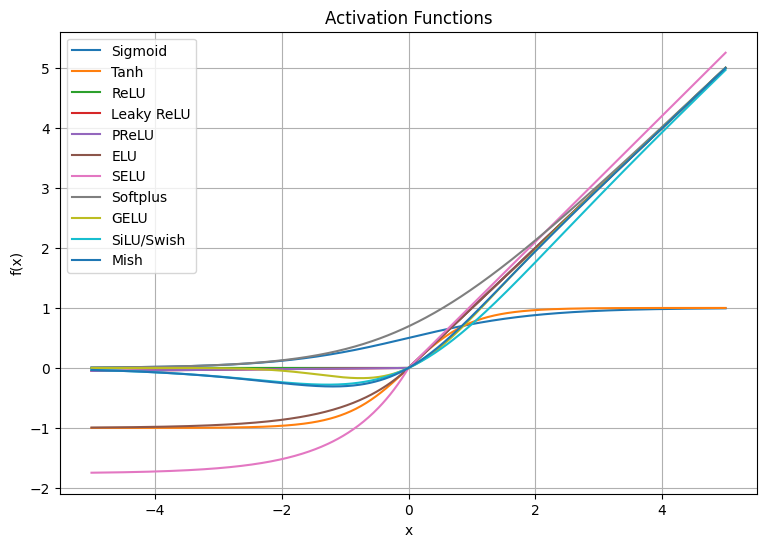

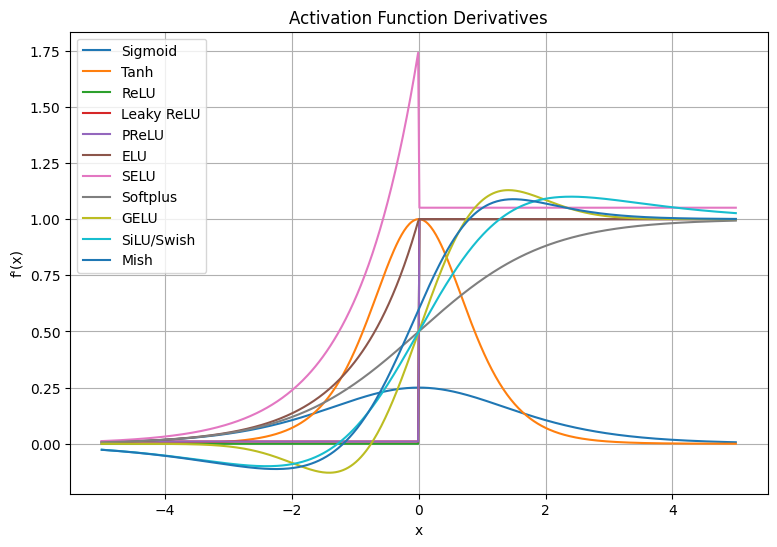

In [27]:
x_values = np.linspace(-5, 5, 500)

plt.figure(figsize=(9, 6))
for name, (activation, _) in ACTIVATIONS.items():
    plt.plot(x_values, activation(x_values), label=name)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Activation Functions")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 6))
for name, (_, derivative) in ACTIVATIONS.items():
    plt.plot(x_values, derivative(x_values), label=name)

plt.xlabel("x")
plt.ylabel("f'(x)")
plt.title("Activation Function Derivatives")
plt.legend()
plt.grid(True)
plt.show()

### G3/G4. Train with Each Activation Function

In [28]:
activation_results = {}
activation_loss_histories = {}

for name, (activation, derivative) in ACTIVATIONS.items():
    print(f"Training with {name}...")

    parameters, loss_history = train(
        X_train,
        y_train,
        learning_rate=0.01,
        epochs=2000,
        activation=activation,
        activation_derivative=derivative,
        seed=42
    )

    train_prob = predict_proba(X_train, parameters, activation)
    test_prob = predict_proba(X_test, parameters, activation)

    train_pred = (train_prob >= 0.5).astype(int)
    test_pred = (test_prob >= 0.5).astype(int)

    train_metric = classification_metrics(y_train, train_pred)
    test_metric = classification_metrics(y_test, test_pred)

    activation_results[name] = {
        "Train Loss": binary_cross_entropy(y_train, train_prob),
        "Test Loss": binary_cross_entropy(y_test, test_prob),
        "Accuracy": test_metric["accuracy"],
        "Precision": test_metric["precision"],
        "Recall": test_metric["recall"],
        "F1": test_metric["f1"],
        "Epochs": 2000,
    }

    activation_loss_histories[name] = loss_history

activation_names = list(activation_results.keys())

print("\n===== ACTIVATION COMPARISON =====")
for name in activation_names:
    print(name, ":", activation_results[name])

Training with Sigmoid...
Training with Tanh...
Training with ReLU...
Training with Leaky ReLU...
Training with PReLU...
Training with ELU...
Training with SELU...
Training with Softplus...
Training with GELU...
Training with SiLU/Swish...
Training with Mish...

===== ACTIVATION COMPARISON =====
Sigmoid : {'Train Loss': np.float64(0.6608063281036904), 'Test Loss': np.float64(0.6581147050939612), 'Accuracy': np.float64(0.631578947368421), 'Precision': np.float64(0.631578947368421), 'Recall': np.float64(1.0), 'F1': np.float64(0.7741935483870968), 'Epochs': 2000}
Tanh : {'Train Loss': np.float64(0.6569427786712843), 'Test Loss': np.float64(0.6544440397600618), 'Accuracy': np.float64(0.631578947368421), 'Precision': np.float64(0.631578947368421), 'Recall': np.float64(1.0), 'F1': np.float64(0.7741935483870968), 'Epochs': 2000}
ReLU : {'Train Loss': np.float64(0.6608144761806146), 'Test Loss': np.float64(0.6581504958938486), 'Accuracy': np.float64(0.631578947368421), 'Precision': np.float64(0

In [29]:
print("\n===== ACTIVATION COMPARISON =====")

headers = ["Activation", "Train Loss", "Test Loss", "Accuracy", "Precision", "Recall", "F1", "Epochs"]

print(f"{headers[0]:<15} {headers[1]:>10} {headers[2]:>10} {headers[3]:>10} "
      f"{headers[4]:>10} {headers[5]:>10} {headers[6]:>10} {headers[7]:>8}")

print("-" * 90)

for name in activation_names:
    r = activation_results[name]
    print(f"{name:<15} "
          f"{r['Train Loss']:>10.4f} "
          f"{r['Test Loss']:>10.4f} "
          f"{r['Accuracy']:>10.4f} "
          f"{r['Precision']:>10.4f} "
          f"{r['Recall']:>10.4f} "
          f"{r['F1']:>10.4f} "
          f"{r['Epochs']:>8}")


===== ACTIVATION COMPARISON =====
Activation      Train Loss  Test Loss   Accuracy  Precision     Recall         F1   Epochs
------------------------------------------------------------------------------------------
Sigmoid             0.6608     0.6581     0.6316     0.6316     1.0000     0.7742     2000
Tanh                0.6569     0.6544     0.6316     0.6316     1.0000     0.7742     2000
ReLU                0.6608     0.6582     0.6316     0.6316     1.0000     0.7742     2000
Leaky ReLU          0.6608     0.6581     0.6316     0.6316     1.0000     0.7742     2000
PReLU               0.6608     0.6581     0.6316     0.6316     1.0000     0.7742     2000
ELU                 0.6582     0.6557     0.6316     0.6316     1.0000     0.7742     2000
SELU                0.0613     0.0944     0.9649     0.9857     0.9583     0.9718     2000
Softplus            0.6592     0.6565     0.6316     0.6316     1.0000     0.7742     2000
GELU                0.6609     0.6582     0.6316     0.

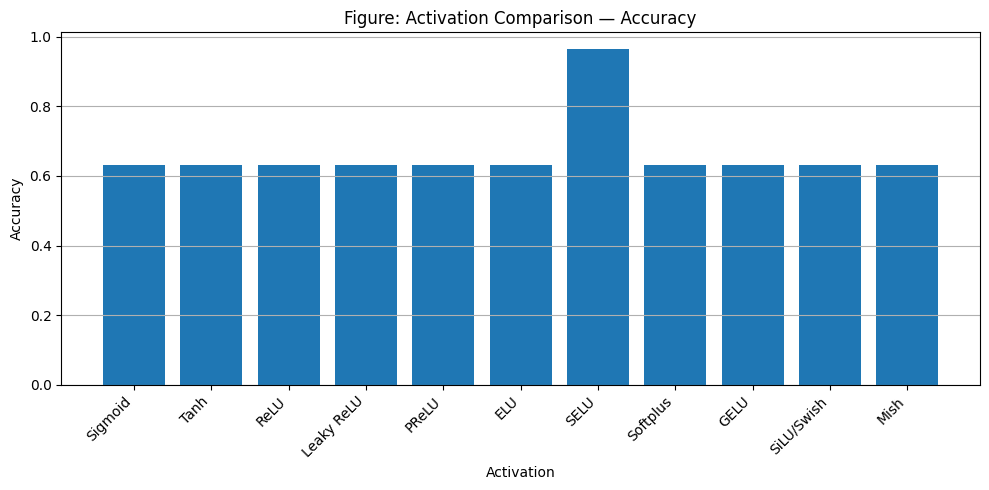

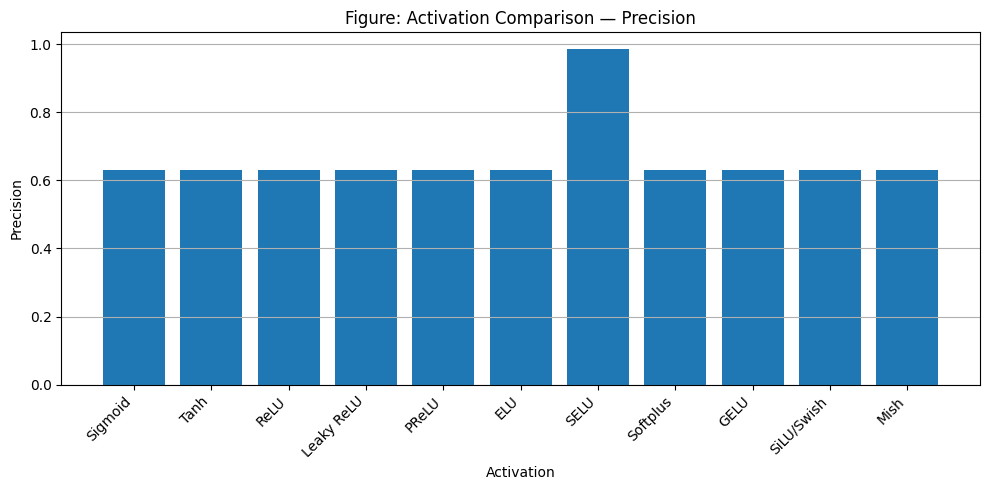

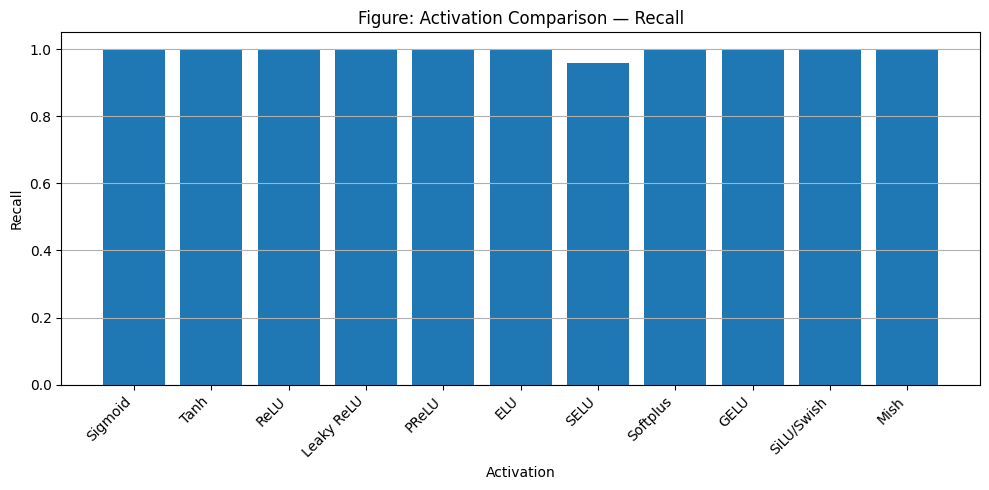

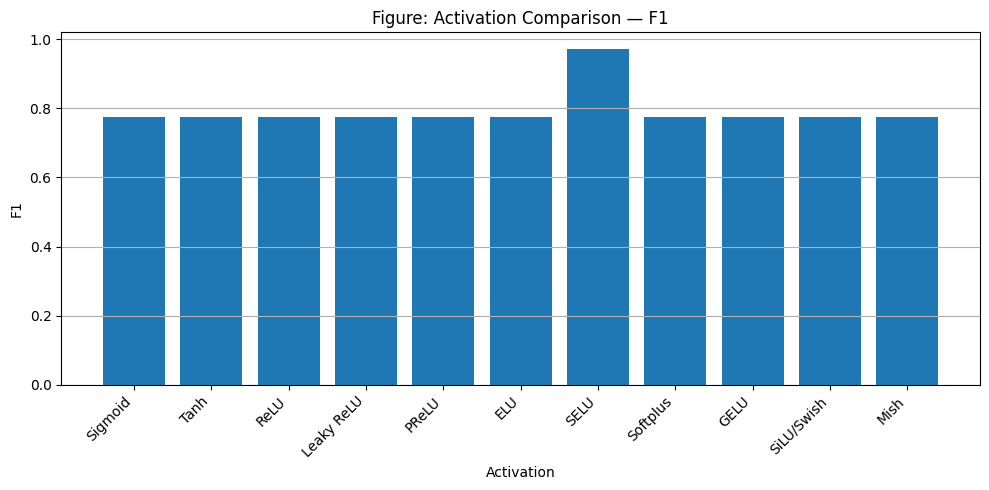

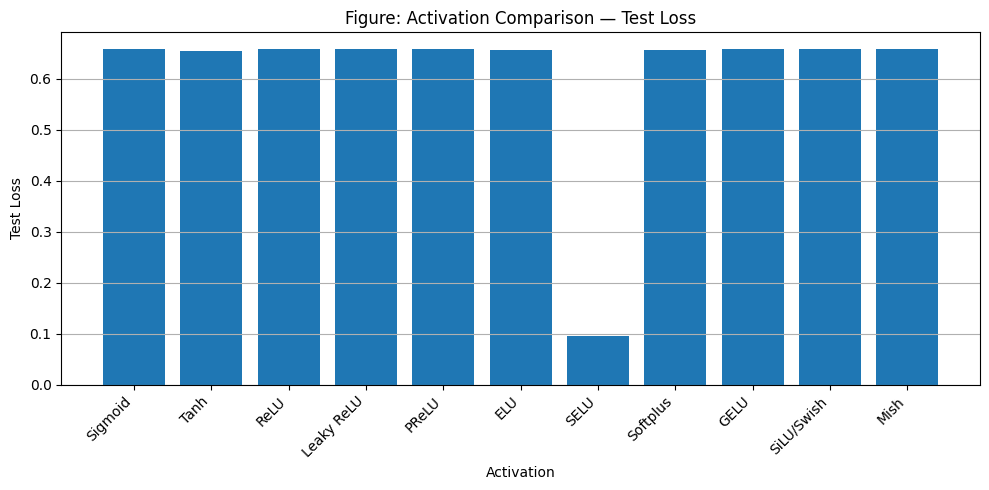

In [30]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "Test Loss"]

for metric in metrics_to_plot:
    values = [activation_results[name][metric] for name in activation_names]

    plt.figure(figsize=(10, 5))
    plt.bar(activation_names, values)
    plt.xlabel("Activation")
    plt.ylabel(metric)
    plt.title(f"Figure: Activation Comparison — {metric}")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

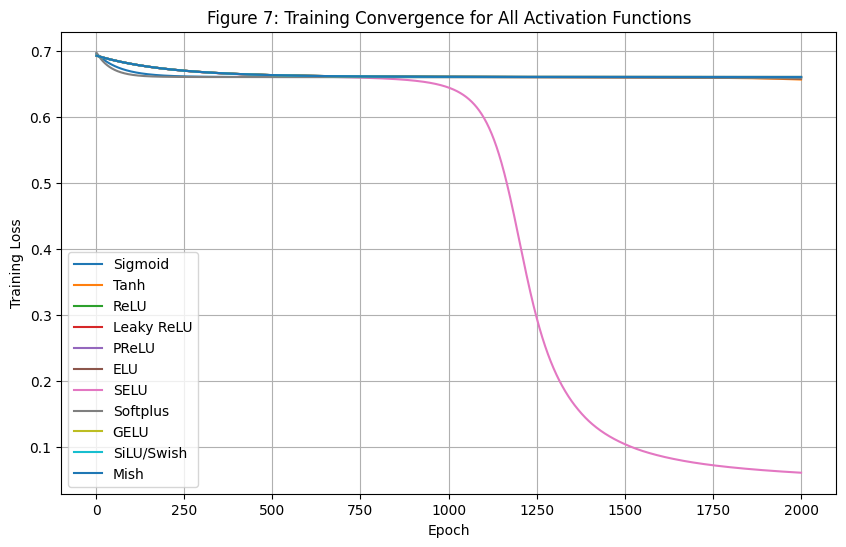

In [31]:
plt.figure(figsize=(10, 6))

for name in activation_names:
    plt.plot(
        range(1, len(activation_loss_histories[name]) + 1),
        activation_loss_histories[name],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Figure 7: Training Convergence for All Activation Functions")
plt.legend()
plt.grid(True)
plt.show()

### G6. Multiple Random Initializations

In [34]:
seeds = [42, 52, 62, 72, 82]
seed_results = []

for seed in seeds:
    print(f"\nTraining with seed= {seed}")
    for name, (activation, derivative) in ACTIVATIONS.items():
        print(f"Activation Function= {name}")
        parameters, loss_history = train(
            X_train,
            y_train,
            learning_rate=0.01,
            epochs=2000,
            activation=activation,
            activation_derivative=derivative,
            seed=seed
        )

        test_prob = predict_proba(X_test, parameters, activation)
        test_pred = (test_prob >= 0.5).astype(int)
        metrics = classification_metrics(y_test, test_pred)

        seed_results.append({
            "Activation": name,
            "Seed": seed,
            "Accuracy": metrics["accuracy"],
            "F1": metrics["f1"],
            "Recall": metrics["recall"],
            "Test Loss": binary_cross_entropy(y_test, test_prob),
        })

seed_summary = {}

for name in activation_names:
    rows = [r for r in seed_results if r["Activation"] == name]

    accuracies = np.array([r["Accuracy"] for r in rows])
    f1_scores = np.array([r["F1"] for r in rows])

    seed_summary[name] = {
        "Mean Accuracy": np.mean(accuracies),
        "Std. Accuracy": np.std(accuracies),
        "Mean F1": np.mean(f1_scores),
        "Std. F1": np.std(f1_scores),
    }

print("===== MULTIPLE-SEED SUMMARY =====")
for name in activation_names:
    print(name, ":", seed_summary[name])


Training with seed= 42
Activation Function= Sigmoid
Activation Function= Tanh
Activation Function= ReLU
Activation Function= Leaky ReLU
Activation Function= PReLU
Activation Function= ELU
Activation Function= SELU
Activation Function= Softplus
Activation Function= GELU
Activation Function= SiLU/Swish
Activation Function= Mish

Training with seed= 52
Activation Function= Sigmoid
Activation Function= Tanh
Activation Function= ReLU
Activation Function= Leaky ReLU
Activation Function= PReLU
Activation Function= ELU
Activation Function= SELU
Activation Function= Softplus
Activation Function= GELU
Activation Function= SiLU/Swish
Activation Function= Mish

Training with seed= 62
Activation Function= Sigmoid
Activation Function= Tanh
Activation Function= ReLU
Activation Function= Leaky ReLU
Activation Function= PReLU
Activation Function= ELU
Activation Function= SELU
Activation Function= Softplus
Activation Function= GELU
Activation Function= SiLU/Swish
Activation Function= Mish

Training wit

### G7/G8. Determine the Best Activation Function

In [42]:
# identifying the best activation under different metrics

best_mean_accuracy = max(
    seed_summary,
    key=lambda name: seed_summary[name]["Mean Accuracy"]
)

best_mean_f1 = max(
    seed_summary,
    key=lambda name: seed_summary[name]["Mean F1"]
)

best_mean_accuracy_stability = min(
    seed_summary,
    key=lambda name: seed_summary[name]["Std. Accuracy"]
)

best_single_run_recall = max(
    activation_results,
    key=lambda name: activation_results[name]["Recall"]
)

best_single_run_test_loss = min(
    activation_results,
    key=lambda name: activation_results[name]["Test Loss"]
)

print("Highest mean accuracy:", best_mean_accuracy)
print("Highest mean F1:", best_mean_f1)
print("Most stable accuracy across seeds:", best_mean_accuracy_stability)
print("Highest recall in seed-42 experiment:", best_single_run_recall)
print("Lowest test loss in seed-42 experiment:", best_single_run_test_loss)


Highest mean accuracy: SELU
Highest mean F1: SELU
Most stable accuracy across seeds: Sigmoid
Highest recall in seed-42 experiment: Sigmoid
Lowest test loss in seed-42 experiment: SELU


## Part H — Dying ReLU Experiment

In [36]:
# Investigate a sufficiently negative first hidden-layer bias

dead_parameters = initialize_parameters(seed=42)
dead_parameters["b1"] = np.full((1, 16), -10.0)

Z1_dead = X_train @ dead_parameters["W1"] + dead_parameters["b1"]
A1_dead = relu(Z1_dead)
D1_dead = relu_derivative(Z1_dead)

fraction_zero = np.mean(A1_dead == 0)
fraction_derivative_zero = np.mean(D1_dead == 0)

print("Fraction of first-layer activations that are zero:", fraction_zero)
print("Fraction of first-layer derivatives that are zero:", fraction_derivative_zero)

print("\nSample Z1 values:")
print(Z1_dead[:5])

print("\nSample ReLU activations:")
print(A1_dead[:5])

print("\nSample ReLU derivatives:")
print(D1_dead[:5])

Fraction of first-layer activations that are zero: 1.0
Fraction of first-layer derivatives that are zero: 1.0

Sample Z1 values:
[[ -9.979586  -9.96678  -10.080229 -10.019885 -10.017282  -9.936203
   -9.978014 -10.051596  -9.998856  -9.968285 -10.028211 -10.042337
   -9.955658  -9.987394 -10.013848  -9.937272]
 [-10.020237 -10.052707  -9.882738  -9.94482  -10.041151 -10.074769
  -10.077935  -9.993783 -10.056821  -9.997604  -9.950783  -9.91345
  -10.043105 -10.016009  -9.965826 -10.09771 ]
 [ -9.943932  -9.959364 -10.088975 -10.035187  -9.961586  -9.968714
   -9.993245 -10.02097   -9.97557   -9.922887 -10.086153 -10.071867
   -9.959718  -9.98933  -10.007797  -9.956725]
 [-10.002434  -9.998269 -10.064554 -10.027397  -9.979194  -9.976521
  -10.033414 -10.044138 -10.036397  -9.984919  -9.992427  -9.989779
   -9.942153 -10.032345 -10.060162  -9.995815]
 [ -9.950148  -9.970024 -10.057683 -10.021721  -9.969948  -9.980157
   -9.961488 -10.005347  -9.944084  -9.985478 -10.043076 -10.022794
   -

## Part I — Matrix Implementation and Verification

In [37]:
# Matrix dimensions for the 30 -> 16 -> 8 -> 1 network

print("X:", X_train.shape)
print("W1:", parameters_relu["W1"].shape)
print("b1:", parameters_relu["b1"].shape)
print("W2:", parameters_relu["W2"].shape)
print("b2:", parameters_relu["b2"].shape)
print("W3:", parameters_relu["W3"].shape)
print("b3:", parameters_relu["b3"].shape)

_, _, _, matrix_cache = forward(
    X_train[:1],
    parameters_relu,
    activation=relu
)

print("Z1:", matrix_cache["Z1"].shape)
print("A1:", matrix_cache["A1"].shape)
print("Z2:", matrix_cache["Z2"].shape)
print("A2:", matrix_cache["A2"].shape)
print("Z3:", matrix_cache["Z3"].shape)
print("A3:", matrix_cache["A3"].shape)

X: (455, 30)
W1: (30, 16)
b1: (1, 16)
W2: (16, 8)
b2: (1, 8)
W3: (8, 1)
b3: (1, 1)
Z1: (1, 16)
A1: (1, 16)
Z2: (1, 8)
A2: (1, 8)
Z3: (1, 1)
A3: (1, 1)


In [38]:
# Scalar-vs-matrix verification for one sample

sample = X_train[0]
W1 = parameters_relu["W1"]
b1 = parameters_relu["b1"]
W2 = parameters_relu["W2"]
b2 = parameters_relu["b2"]
W3 = parameters_relu["W3"]
b3 = parameters_relu["b3"]

z1_scalar = np.array([
    np.dot(sample, W1[:, j]) + b1[0, j]
    for j in range(16)
])

a1_scalar = relu(z1_scalar)

z2_scalar = np.array([
    np.dot(a1_scalar, W2[:, j]) + b2[0, j]
    for j in range(8)
])

a2_scalar = relu(z2_scalar)

z3_scalar = np.dot(a2_scalar, W3[:, 0]) + b3[0, 0]
a3_scalar = sigmoid(z3_scalar)

_, _, a3_matrix, matrix_cache = forward(
    X_train[:1],
    parameters_relu,
    activation=relu
)

print("Z1 agreement:", np.allclose(z1_scalar, matrix_cache["Z1"][0]))
print("A1 agreement:", np.allclose(a1_scalar, matrix_cache["A1"][0]))
print("Z2 agreement:", np.allclose(z2_scalar, matrix_cache["Z2"][0]))
print("A2 agreement:", np.allclose(a2_scalar, matrix_cache["A2"][0]))
print("Z3 agreement:", np.allclose(z3_scalar, matrix_cache["Z3"][0]))
print("A3 agreement:", np.allclose(a3_scalar, a3_matrix[0, 0]))

Z1 agreement: True
A1 agreement: True
Z2 agreement: True
A2 agreement: True
Z3 agreement: True
A3 agreement: True


## Part J — Learning-Rate Experiment

In [39]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
learning_rate_results = {}
learning_rate_histories = {}

for lr in learning_rates:
    parameters, loss_history = train(
        X_train,
        y_train,
        learning_rate=lr,
        epochs=2000,
        activation=relu,
        activation_derivative=relu_derivative,
        seed=42
    )

    test_prob = predict_proba(X_test, parameters, relu)
    test_pred = (test_prob >= 0.5).astype(int)
    metrics = classification_metrics(y_test, test_pred)

    learning_rate_results[lr] = {
        "Epochs": 2000,
        "Test Loss": binary_cross_entropy(y_test, test_prob),
        "Accuracy": metrics["accuracy"],
        "F1": metrics["f1"],
    }

    learning_rate_histories[lr] = loss_history

print("===== LEARNING RATE COMPARISON =====")
for lr in learning_rates:
    print(lr, ":", learning_rate_results[lr])

===== LEARNING RATE COMPARISON =====
0.001 : {'Epochs': 2000, 'Test Loss': np.float64(0.6718986943597137), 'Accuracy': np.float64(0.631578947368421), 'F1': np.float64(0.7741935483870968)}
0.01 : {'Epochs': 2000, 'Test Loss': np.float64(0.6581504958938486), 'Accuracy': np.float64(0.631578947368421), 'F1': np.float64(0.7741935483870968)}
0.05 : {'Epochs': 2000, 'Test Loss': np.float64(0.10270895604096597), 'Accuracy': np.float64(0.956140350877193), 'F1': np.float64(0.9645390070921985)}
0.1 : {'Epochs': 2000, 'Test Loss': np.float64(0.1346479315943712), 'Accuracy': np.float64(0.9649122807017544), 'F1': np.float64(0.971830985915493)}


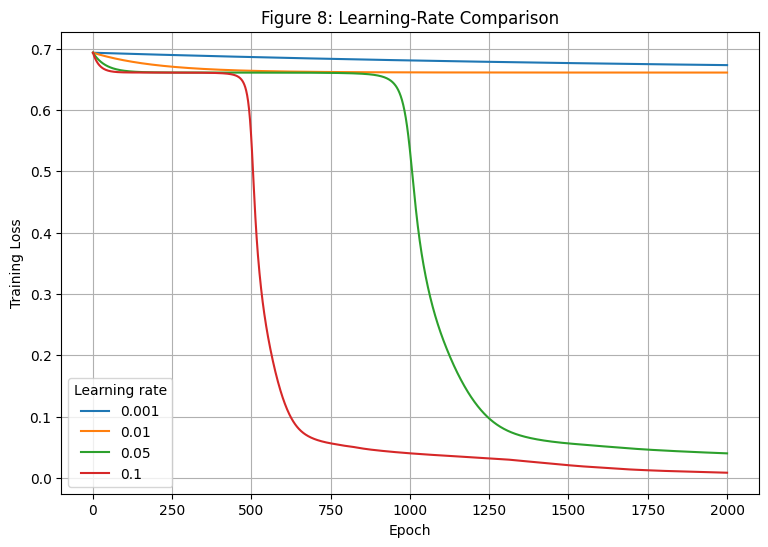

In [40]:
plt.figure(figsize=(9, 6))

for lr in learning_rates:
    plt.plot(
        range(1, len(learning_rate_histories[lr]) + 1),
        learning_rate_histories[lr],
        label=str(lr)
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Figure 8: Learning-Rate Comparison")
plt.legend(title="Learning rate")
plt.grid(True)
plt.show()

## Part K — Final Integrated Program

===== BREAST CANCER WISCONSIN: MLP =====
Training samples: 455
Testing samples: 114
Number of features: 30

===== TRAINING =====
Final training loss: 0.6608144761806146
Epochs: 2000

===== TEST RESULTS =====
Test loss: 0.6581504958938486
Accuracy: 0.631578947368421
Precision: 0.631578947368421
Recall: 1.0
F1-score: 0.7741935483870968

Confusion Matrix:
[[ 0 42]
 [ 0 72]]


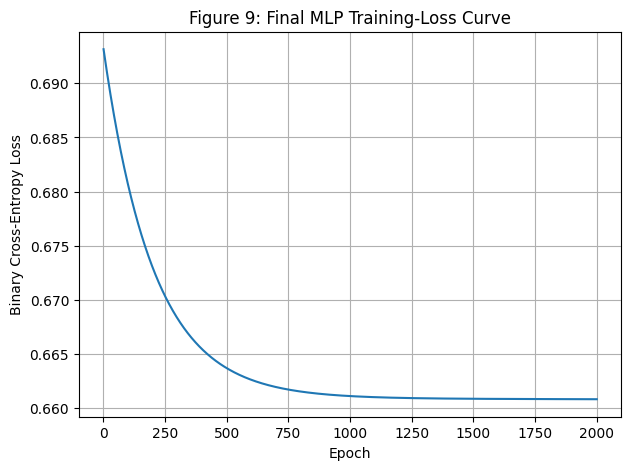

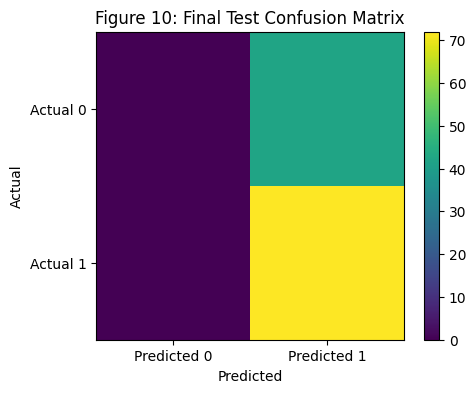

In [41]:
# Final clean implementation using the required ReLU -> ReLU -> Sigmoid architecture

def final_sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))


def final_sigmoid_derivative(x):
    s = final_sigmoid(x)
    return s * (1 - s)


def final_relu(x):
    return np.maximum(0, x)


def final_relu_derivative(x):
    return (x > 0).astype(float)


def final_binary_cross_entropy(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)

    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )


def final_initialize_parameters(seed=42):
    rng = np.random.default_rng(seed)

    return {
        "W1": rng.standard_normal((30, 16)) * 0.01,
        "b1": np.zeros((1, 16)),
        "W2": rng.standard_normal((16, 8)) * 0.01,
        "b2": np.zeros((1, 8)),
        "W3": rng.standard_normal((8, 1)) * 0.01,
        "b3": np.zeros((1, 1)),
    }


def final_forward(X, parameters):
    Z1 = X @ parameters["W1"] + parameters["b1"]
    A1 = final_relu(Z1)

    Z2 = A1 @ parameters["W2"] + parameters["b2"]
    A2 = final_relu(Z2)

    Z3 = A2 @ parameters["W3"] + parameters["b3"]
    A3 = final_sigmoid(Z3)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "A3": A3,
    }

    return A3, cache


def final_backward(X, y, cache, parameters):
    y = np.asarray(y).reshape(-1, 1)
    m = len(X)

    dZ3 = cache["A3"] - y
    dW3 = cache["A2"].T @ dZ3 / m
    db3 = np.mean(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ parameters["W3"].T
    dZ2 = dA2 * final_relu_derivative(cache["Z2"])
    dW2 = cache["A1"].T @ dZ2 / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ parameters["W2"].T
    dZ1 = dA1 * final_relu_derivative(cache["Z1"])
    dW1 = X.T @ dZ1 / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    return {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
        "W3": dW3,
        "b3": db3,
    }


def final_update_parameters(parameters, gradients, learning_rate):
    for key in parameters:
        parameters[key] -= learning_rate * gradients[key]
    return parameters


def final_train(X, y, learning_rate=0.01, epochs=2000, seed=42):
    parameters = final_initialize_parameters(seed)
    loss_history = []

    for _ in range(epochs):
        predictions, cache = final_forward(X, parameters)

        loss = final_binary_cross_entropy(y, predictions)
        loss_history.append(loss)

        gradients = final_backward(X, y, cache, parameters)
        parameters = final_update_parameters(
            parameters,
            gradients,
            learning_rate
        )

    return parameters, loss_history


def final_predict(X, parameters, threshold=0.5):
    probabilities, _ = final_forward(X, parameters)
    return (probabilities.ravel() >= threshold).astype(int), probabilities.ravel()


# Run the final program
final_parameters, final_loss_history = final_train(
    X_train,
    y_train,
    learning_rate=0.01,
    epochs=2000,
    seed=42
)

final_train_pred, final_train_prob = final_predict(X_train, final_parameters)
final_test_pred, final_test_prob = final_predict(X_test, final_parameters)

final_train_metrics = classification_metrics(y_train, final_train_pred)
final_test_metrics = classification_metrics(y_test, final_test_pred)

print("===== BREAST CANCER WISCONSIN: MLP =====")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", X_train.shape[1])

print("\n===== TRAINING =====")
print("Final training loss:",
      final_binary_cross_entropy(y_train, final_train_prob))
print("Epochs:", len(final_loss_history))

print("\n===== TEST RESULTS =====")
print("Test loss:",
      final_binary_cross_entropy(y_test, final_test_prob))
print("Accuracy:", final_test_metrics["accuracy"])
print("Precision:", final_test_metrics["precision"])
print("Recall:", final_test_metrics["recall"])
print("F1-score:", final_test_metrics["f1"])

print("\nConfusion Matrix:")
print(final_test_metrics["confusion_matrix"])

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(final_loss_history) + 1), final_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Figure 9: Final MLP Training-Loss Curve")
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(final_test_metrics["confusion_matrix"], interpolation="nearest")
plt.colorbar()
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Figure 10: Final Test Confusion Matrix")
plt.show()

# XOR Experiment
### Does the perceptron converge?
No. XOR is not linearly separable, so the perceptron does not converge.

### What accuracy does it achieve?
50%.

### How do mistakes change across epochs?
The number of mistakes does not converge to zero; it starts with 3 and soon reaches 4 (100%).
### Can one straight decision boundary separate the classes?
No.
### Why?
The XOR samples form two diagonally opposite classes, so no single straight line can separate them. A perceptron produces only a linear decision boundary, while XOR requires a non-linear boundary.


# Feature Scaling

Feature scaling is important because the input features have very different ranges and units. Standardization puts them on comparable scales, preventing large-valued features from dominating gradient updates and improving gradient-descent optimization.

# Training Loss

The training loss decreases during learning. This indicates that the network is adjusting its parameters to reduce the binary cross-entropy error and learn from the training data.

# MLP Training Results
Final training loss: 0.6608\
Final test loss: 0.6582\
Training accuracy: 62.64%\
Test accuracy: 63.16%\
Precision: 63.16%\
Recall: 100%\
F1-score: 77.42%\
Epochs: 2000\

The model predicted every test sample as the positive class, giving 42 FP, 72 TP, 0 TN, and 0 FN. Thus, recall is perfect, but accuracy and precision are relatively low.

# Activation Convergence Analysis
### Which activation converges fastest?
SELU shows the strongest convergence toward a substantially lower loss.
### Which reaches the lowest training loss?
SELU, with a training loss of 0.0613.
### Which achieves the lowest test loss?
SELU, with a test loss of 0.0944.
### Which achieves the highest test accuracy?
SELU, with 96.49%.
### Which achieves the highest F1-score?
SELU, with 97.18%.
### Which shows unstable or slow convergence?
Most other activations converge very slowly and plateau around a loss of 0.65–0.66, whereas SELU eventually makes a strong descent.

# Best Activation Function

### Highest Mean Accuracy
SELU

### Highest Mean F1-Score
SELU

### Most Stable Accuracy Across Seeds
Sigmoid

### Highest Recall in Seed-42 Experiment
Sigmoid

### Lowest Test Loss in Seed-42 Experiment
SELU

### Final Activation Choice
SELU provides the best overall performance, with the highest mean accuracy and F1-score and the lowest test loss.

# Dying ReLU

### Fraction of Zero Activations
100%

### Fraction of Zero Derivatives
100%

### Interpretation
All first-layer Z1 values are negative, so ReLU outputs zero for every neuron and its derivatives are also zero. This demonstrates the dying ReLU problem.

# Matrix Implementation and Verification

### Verification
Z1 agreement: True
A1 agreement: True
Z2 agreement: True
A2 agreement: True
Z3 agreement: True
A3 agreement: True

### Interpretation
The scalar and matrix implementations produce identical results for the tested sample.

# Learning-Rate Experiment

### Results
0.001: Test Loss = 0.6719, Accuracy = 63.16%
0.01: Test Loss = 0.6582, Accuracy = 63.16%
0.05: Test Loss = 0.1027, Accuracy = 95.61%
0.1: Test Loss = 0.1346, Accuracy = 94.74%

### Best Learning Rate
0.05 gives the best final test performance. A learning rate of 0.1 converges faster initially, but 0.05 achieves lower final loss and higher accuracy.

# Final Result Interpretation

### Baseline ReLU Model
Test Accuracy: 63.16%
Precision: 63.16%
Recall: 100%
F1-score: 77.42%
Test Loss: 0.6582

### Confusion Matrix
[[0 42]
 [0 72]]

### Interpretation
The model predicts every test sample as positive. Therefore, it has 100% recall but produces 42 false positives, resulting in low accuracy and precision.

### SELU Comparison
SELU achieves 96.49% accuracy, 98.57% precision, 95.83% recall, and 97.18% F1-score with a test loss of 0.0944.

### Conclusion
SELU is the best overall activation function among those tested.